---
# RL Basics 2: Prediction and Control
---

In `RL01` we computed value functions **exactly**, by solving a linear system built
from the environment's transition probabilities $p(s' \mid s, a)$.

That is a luxury. In general the model is unknown: the agent can only **act and observe**.
This notebook covers what replaces dynamic programming in that setting.

- **Prediction** — estimating $V^\pi$ for a *given* policy, from sampled trajectories:
  Every-Visit Monte Carlo and TD(0).
- **Control** — finding a *good* policy: SARSA and $Q$-learning.

Each of these is the sampled counterpart of a method from `RL01`. Monte Carlo estimates the
same $V^\pi$ the direct solve computes; TD(0) is iterative policy evaluation with the exact
expectation replaced by a single sampled successor; SARSA and $Q$-learning are the sampled
analogues of policy iteration and value iteration.

In this notebook you will find some **⭐ Exercise**s where you need to implement missing
parts in the code. When you need to complete some code, the section is marked as:
```python
# Your code goes here: -------------------------------------

# ----------------------------------------------------------
```

# ⚙️ Setup

The environment, policies, `rollout` and `evaluate_policy` you implemented in `RL00` now
live in the `rl_basics` package, so this notebook runs standalone from a fresh kernel.

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from tqdm import tqdm

from rl_basics.utils import *
from rl_basics.core import *
setup()

CLIFF_WALKING_ENV_NAME = 'CliffWalking-RLSS-v0'

seed_everything(42)

# 📈 Prediction

Given a policy $\pi$, **prediction** is concerned with the estimation of the value function $V_\gamma^\pi$ and the $Q$ function $Q_\gamma^\pi$, defined in `RL00`:

$$
V_\gamma^\pi(s) = \mathbb{E}_{P,\pi}\left[ \sum_{h = 0}^{+\infty} \gamma^h R(S_h, A_h) \mid S_0 = s \right], \qquad Q_\gamma^\pi(s, a) = \mathbb{E}_{P, \pi}\left[ \sum_{h = 0}^{+\infty} \gamma^h R(S_h, A_h) \mid S_0 = s, A_0 = a \right].
$$

In `RL01` we computed $V_\gamma^\pi$ **exactly**, by solving the linear system $(I - \gamma P^\pi) V^\pi = R^\pi$. That required knowing the transition probabilities $P(s' \mid s, a)$. Here we do not know them, and must fall back on **samples**: trajectories generated by running the policy in the environment.

In what follows, we will focus **just** on the estimation of the **value function**.

**Dataset.** Prediction methods operate on a dataset of trajectories $\mathcal{T} = (\tau_i)_{i = 1}^N$. Let's generate a dataset of this kind by running the heuristic policy on the _cliff walking_ environment.

_Remark._ We drop the `frames` to reduce the memory footprint.

In [3]:
seed_everything(42)

NUM_TRAJECTORIES = 500

env     = gym.make(CLIFF_WALKING_ENV_NAME, render_mode='rgb_array')
policy  = CliffWalkingHeuristicPolicy()

trajectories = [ rollout(env, policy, render=False) for _ in tqdm(range(NUM_TRAJECTORIES), desc="Generating Trajectories") ]

Generating Trajectories: 100%|██████████| 500/500 [00:00<00:00, 3455.62it/s]


**Monte Carlo Methods.** Monte Carlo methods rely on the _sample mean_ to estimate the expected cumulative reward. A naive approach is to simulate the policy on the environment, keep track of each trajectory which starts in the desired state $s$:
$$
\hat{V}(s) = \frac{1}{N(s)} \sum_{i = 1}^N \mathbb{I}[S_0(\tau_i) = s] G_\gamma(\tau_i),
$$
where $N(s) = \sum_{i=1}^N \mathbb{I}[S_0(\tau_i) = s]$ is the number of trajectories which start in state $s \in \mathcal{S}$.
This approach is known as _First-Visit Monte Carlo_.

It can be improved as follows: we exploit all the information inside a trajectory, by considering all the sub-trajectory at each starting time step $h$. In particular, we work on the dataset:

<center>

$\mathcal{T}^{\text{ev}} = (\tau_{i,h:}$ where $i \in \{ 1, \dots, N \}, h \in \{ 0, \dots, H(\tau_i) - 1 \} ).$

</center>

Then, we apply the same estimator of First-Visit Monte Carlo, but on this extended dataset $\mathcal{T}^{\text{ev}}$. In this way, we get a sample for each state $s \in \mathcal{S}$.
The resulting estimator, known as _Every-Visit Monte Carlo_, is:

<center>

$\hat{V}^{\text{ev}}(s) = \frac{1}{N^{\text{ev}}(s)} \sum_{i = 1}^N \sum_{h = 0}^{H(\tau_i) - 1} \mathbb{I}[S_0(\tau_{i,h:}) = s] G_\gamma(\tau_{i,h:})$,

</center>

where $N^{\text{ev}}(s) = \sum_{i=1}^N \sum_{h = 0}^{H(\tau_i) - 1} \mathbb{I}[S_0(\tau_{i,h:}) = s]$.

**⭐ Exercise.** Complete the `every_visit_monte_carlo` function by implementing the Every-Visit estimator. The function takes in input `trajectories`, i.e., the dataset $\mathcal{T}$, and the `discount_factor` $\gamma$. We assume that the environment is a grid world with `num_rows` rows and `num_cols` columns which are taken in input by the function. In this way we can store the estimates as a bidimensional `np.ndarray`.

In [20]:
def every_visit_monte_carlo(trajectories, num_rows, num_cols, discount_factor=1.0):
    returns_sum_ev = np.zeros(shape=(num_rows, num_cols))
    N_ev           = np.zeros(shape=(num_rows, num_cols))

    for trajectory in trajectories:
        states, _, rewards = trajectory

        # Your code goes here: -------------------------------------
        G = 0
        returns = []

        for s in range(len(states)):
            if s !=len(states) - 1:
                returns_sum_ev[states[s]] += discount_factor**s * rewards[s]
            N_ev[states[s]] += 1

        # ----------------------------------------------------------

    # Suppress errors for unvisited states    
    with np.errstate(divide='ignore', invalid='ignore'):
        V_ev = returns_sum_ev / N_ev

    return V_ev

In [26]:
print(trajectories[5])

([(2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (3, 11)], [1, 1, 1, 1, 1, 1, 1, 2], [-1, -1, -1, -1, -1, -1, -1, -1])


You can use the `plot_gridworld_values` utility to **visualize** the estimated **value function**.

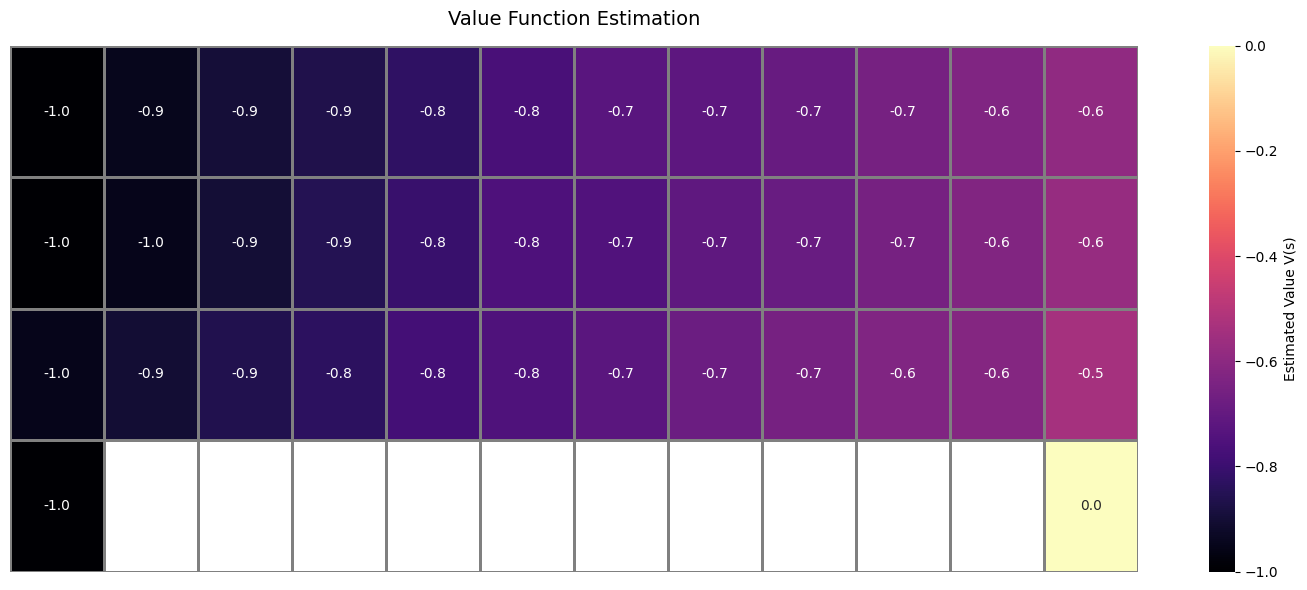

In [27]:
seed_everything(42)

V_ev = every_visit_monte_carlo(
    trajectories=trajectories, 
    num_rows=4, 
    num_cols=12, 
    discount_factor=0.9
)

plot_gridworld_values(V=V_ev, gif_path='https://gymnasium.farama.org/_images/cliff_walking.gif')

**Temporal Difference Methods.**
Monte Carlo methods treat the environment largely as a black box, waiting until the end of a trajectory to calculate the actual sampled return. This ignores the underlying structure of the MDP. Temporal Difference (TD) learning, conversely, exploits the Markov property by *bootstrapping*: it updates the value of a state based on the current estimated value of the successor states.

The simplest form, **TD(0)**, relies entirely on the 1-step return:
$$G_\gamma^{(1)}(R, S', \hat{V}) = R + \gamma \hat{V}(S').$$
Observe how, because of the bootstrapping, the estimation depends on the current estimate of the value function.
In particular, the estimation of the value function is computed through an iterative approach.
* We start from the initialization $\hat{V}^{\text{td}}(s) \gets 0$ and $N(s) \gets 0$ for every $s \in \mathcal{S}$.
* For every $i \in \{ 1, \dots, N \}$, $h \in \{ 0, \dots, H(\tau_i) - 1 \}$, we do the **update**:
$$N(S_h(\tau_i)) \gets N(S_h(\tau_i)) + 1,$$
$$\hat{V}^{\text{td}}(S_h(\tau_i)) \gets \hat{V}^{\text{td}}(S_h(\tau_i)) + \alpha_{N(S_h(\tau_i))} \left(G_\gamma^{(1)}(R_h(\tau_i), S_{h+1}(\tau_i), \hat{V}^{\text{td}}) - \hat{V}^{\text{td}}(S_h(\tau_i))\right).$$

The term $\alpha_{N(s)}$ is known as the _learning rate_ for state $s$. A sufficient condition for convergence is given by the Robbins-Monro conditions: $\sum_{n=1}^{+\infty} \alpha_n = +\infty$, $\sum_{n=1}^{+\infty} \alpha_n^2 < +\infty$, e.g., $\alpha_n = 1/n$.

**⭐ Exercise.** Complete the `temporal_difference_0` function by implementing the TD(0) update with $\alpha_n = 1/n$. The function takes in input `trajectories`, i.e., the dataset $\mathcal{T}$ and the `discount_factor` $\gamma$. We assume that the environment is a grid world with `num_rows` rows and `num_cols` columns which are taken in input by the function. In this way we can store the estimates as a bidimensional `np.ndarray`.

In [30]:
def temporal_difference_0(trajectories, num_rows, num_cols, discount_factor=1.0):
    V_td = np.zeros(shape=(num_rows, num_cols))
    N    = np.zeros(shape=(num_rows, num_cols))

    for trajectory in trajectories:
        # Your code goes here: -------------------------------------
        states, actions, rewards = trajectory
        
        for h in range(len(rewards)):
            if h != len(states) - 1:  # Skip terminal states
                s = states[h]
                r = rewards[h]
                s_next = states[h + 1]
                
                # Update the value function using TD(0) update rule
                V_td[s] += 1/(h+1) * (r + discount_factor * V_td[s_next] - V_td[s])
                N[s] += 1
        # ----------------------------------------------------------
            
    return V_td

Let's **visualize** the estimated **value function**.

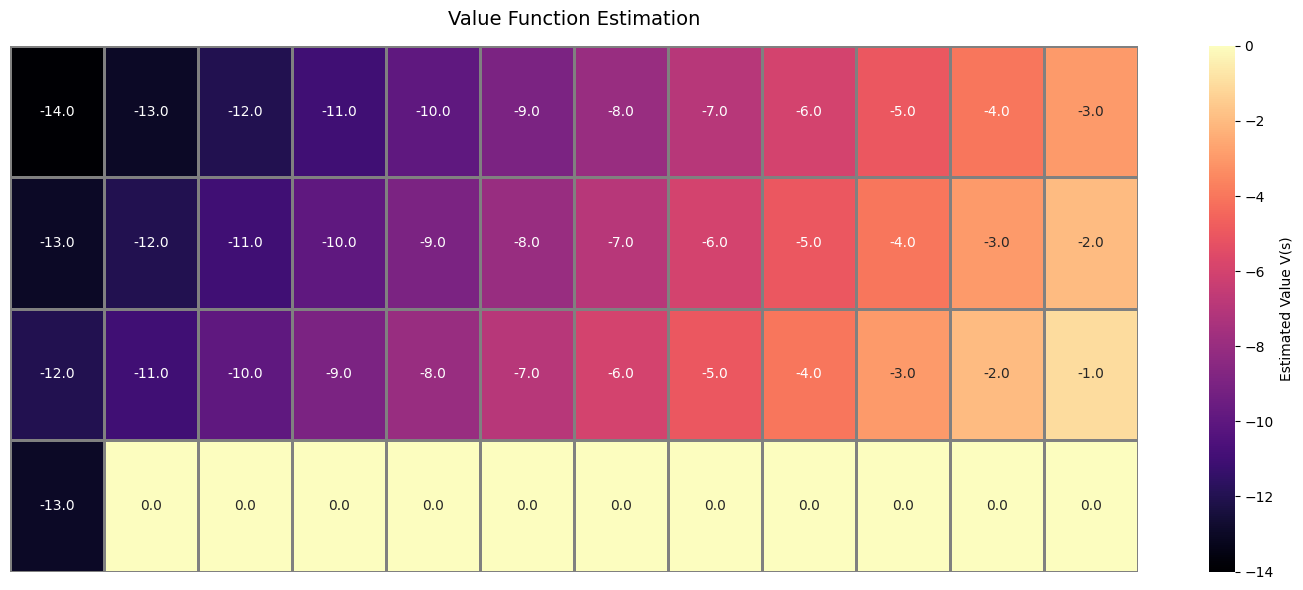

In [31]:
seed_everything(42)

V_td = temporal_difference_0(
    trajectories=trajectories,
    num_rows=4,
    num_cols=12,
    discount_factor=1.0
)

plot_gridworld_values(V=V_td, gif_path='https://gymnasium.farama.org/_images/cliff_walking.gif')

# 🎮 Control

_Recall from `RL01`._ With a known model, we found the optimal policy by iterating the Bellman **optimality** operator until it converged to $V^*$, then reading off the greedy policy. The equation below is that same characterisation of optimality. The difference in this section is that $Q^*$ must now be **estimated from experience** rather than computed from $P$ and $R$.

**Bellman Optimality Equation.** _Control_ is concerned with _learning the optimal policy_, i.e., $\pi^* \in \arg\max_{\pi}{J_\gamma^{\pi}}$, by interacting with the environment. From the theory of MDPs, we know that a policy is optimal, if and only if it satisfies the so-called _Bellman Optimality Equation_:

<center>

$V^{\pi^*}(s) = \max_{a \in \mathcal{A}} Q^{\pi^*}(s, a)$ for every $s \in \mathcal{S}$.

</center>

For this reason, given the optimal $Q$ function: $Q^* = Q^{\pi^*}$ for some optimal policy $\pi$, we have that the _greedy_ policy $\pi^{\text{g}}_{Q^*} = \delta_{a^{\text{g}}_{Q^*}(s)}$ with $a^{\text{g}}_{Q^*}(s) \in \arg\max_{a \in \mathcal{A}} Q^*(s, a)$ is optimal.
The approaches that we tackle in this section are concerned with the estimation of $Q^*$, obtaining a policy which converges to the optimal one by computing the greedy policy w.r.t. the current estimate $\hat{Q}^*$.

**$\epsilon$-Greedy Policies.** The greedy policy is optimal once our estimate of the optimal $Q$ function has converged: $\hat{Q}^* \rightarrow Q^*$, but it has a critical issue: being deterministic, it doesn't allow to learn the transition matrix properly and thus to do a correct estimation of the $Q$ function.

This problem is solved by introducing the so-called $\epsilon$-greedy policies $\pi^{\text{g}}_{\hat{Q}^*, \epsilon}$, which are greedy w.p. $1 - \epsilon$ and random w.p. $\epsilon$:
$$
\mathbb{P}_{A \sim \pi^{\text{g}}_{\hat{Q}^*, \epsilon}(s)}[A = a] = \begin{cases}
    1-\epsilon+\frac{\epsilon}{|\mathcal{A}|} & \text{ if } a = a^{\text{g}}_{\hat{Q}^*}(s) \\
    \frac{\epsilon}{|\mathcal{A}|} & \text{otherwise}
\end{cases}.
$$

During learning, the value of $\epsilon$ is reduced towards $0$, e.g.:
$$
\epsilon_t = \frac{c}{t}
$$
where $c > 0$ is a constant and $t$ typically represents the episode index or global time step. Alternatively, an exponential decay is often used in empirical settings:
$$
\epsilon_t = \max(\epsilon_{\text{min}}, \epsilon_0 \exp(-\lambda t))
$$
with initial value $\epsilon_0 = 1.0$, a decay rate $\lambda > 0$, and a minimum exploration floor $\epsilon_{\text{min}}$.
<br> Let's define a scheduler for epsilon:

In [32]:
def epsilon(t, epsilon_0=1.0, epsilon_min=1e-2, lambd=1e-3):
    return max(epsilon_min, epsilon_0 * np.exp(-lambd * t))

In rigorous tabular settings, a polynomial schedule like $\epsilon_t \propto 1/t$ is particularly relevant because it satisfies the conditions for being **Greedy in the Limit with Infinite Exploration (GLIE)**. A GLIE schedule guarantees two crucial properties:
1. All state-action pairs are explored infinitely often ($\lim_{t \to \infty} N_t(s,a) = \infty$).
2. The policy asymptotically converges to a purely greedy policy ($\lim_{t \to \infty} \epsilon_t = 0$).

**⭐ Exercise.** Complete the code of the `EpsilonGreedyPolicy` class which has an internal attribute `Q` which corresponds to the (estimated) $Q$ function, and one internal attribute `epsilon`. The `__init__` method takes in input the shape (with the `numpy` meaning) of the discrete state space with the attribute `state_shape`.
The actions, instead are $\mathcal{A} = \{ 0, \dots, N_{\mathcal{A}} - 1 \}$, where the cardinlaity of the actions set $N_{\mathcal{A}}$ is taken in input by the `__init__` method as `actions_cardinality`.

In [33]:
class EpsilonGreedyPolicy(Policy):
    def __init__(self, state_shape, epsilon, actions_cardinality):
        self.Q_hat = np.zeros(shape=(*state_shape, actions_cardinality))
        self.epsilon = epsilon
        self.actions_cardinality = actions_cardinality
    
    def get_action(self, state):
        # Your code goes here: -------------------------------------
        if np.random.rand() <= self.epsilon:
            return np.random.randint(0, self.actions_cardinality)
        else:
            return np.argmax(self.Q_hat[state])
        # ----------------------------------------------------------

**SARSA.** _SARSA_ stands for State, Action, Reward, next State, next Action. It is an _on-policy_ control algorithm, in the sense that it estimates the optimal $Q$ function by choosing actions according to the current $\epsilon$-greedy policy $\pi^{\text{g}}_{\hat{Q}^*_t, \epsilon_t}$, which is being improved.
<br> The algorithm works as follows.
<br> **Initialize** $\hat{Q}^*(s, a) \gets 0$, $N(s, a) \gets 0$, for every $s \in \mathcal{S}, a \in \mathcal{A}$ and $t \gets 1$
<br> **For every episode**:
<br> **Sample** $S \sim \mu_0$
<br> **Sample** $A \sim \pi^{\text{g}}_{\hat{Q}^*, \epsilon_t}(S)$
<br> **Repeat until end of the episode**:
1. **Increment** $t \gets t + 1$ 
2. **Take action** $A$ and observe reward $R$ and next-state $S'$
3. **Sample** $A' \sim \pi^{\text{g}}_{\hat{Q}^*, \epsilon_t}(S')$
4. **Increment** $N(S, A) \gets N(S, A) + 1$
5. **Update** $\hat{Q}^*(S, A) \gets \hat{Q}^*(S, A) + \alpha_{N(S, A)} (R + \gamma \hat{Q}^*(S', A') - \hat{Q}^*(S, A))$
6. **Update** $S \gets S'$, $A \gets A'$

_Remark._ We chose $\alpha_n$ which satisfies the Robbins-Monro conditions.

**⭐ Exercise.** Complete the implementation of SARSA for environments with state space with shape `state_shape` (with the `numpy` meaning) and action space $\mathcal{A} = \{ 0, \dots, N_{\mathcal{A}} - 1 \}$, where $N_{\mathcal{A}}$ is provided as `actions_cardinality`. The function takes in input `n_episodes` which is the number of episodes used for training.
The `eval_every` attribute is the number of episodes after which we run an evaluation of the current policy: this behavior is already implemented.
Use the learning rate $\alpha_n = 0.1 \frac{c}{c+n}$ where $c$ is taken in input by the algorihtm as `c`.

_Hint._ Remember to update $\epsilon_t$ and $\hat{Q}^*$ in the $\epsilon$-greedy policy. You can do so by accessing directly the attributes.

In [34]:
def SARSA(env, state_shape, actions_cardinality, discount_factor=1.0, c=200., n_episodes=5000, eval_every=20):
    t = 1
    policy = EpsilonGreedyPolicy(state_shape, epsilon(t), actions_cardinality)
    N = np.zeros(shape=(*state_shape, actions_cardinality))
    
    mean_returns = []
    margins_of_error = []
    evaluation_count = 0
    
    for episode in range(n_episodes):
        state, _ = env.reset()
        action = policy.get_action(state) 
        done = False

        while not done:
            # Your code goes here: -------------------------------------
            next_state, reward, terminated, truncated, _ = env.step(action)
            t += 1
            policy.epsilon = epsilon(t)
            policy_action = policy.get_action(next_state)
            N[state][action] += 1
            alpha = 0.1 *(c/(c+episode))
            policy.Q_hat[state][action] += alpha * (reward + discount_factor * policy.Q_hat[next_state][policy_action] - policy.Q_hat[state][action])
            done = terminated or truncated
            # ----------------------------------------------------------

        if (episode + 1) % eval_every == 0:
            mean_return, margin = evaluate_policy(env, policy, discount_factor=discount_factor)
            mean_returns.append(mean_return)
            margins_of_error.append(margin)

            evaluation_count += 1
            if evaluation_count % 20 == 0:
                clear_output(wait=True)

    return policy, mean_returns, margins_of_error

Let's **try** the SARSA algorithm on the _cliff walking_ environment. The `plot_training_results` function allows to visualize the evolution of the performance of the policy during the training.

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 6666.30it/s]


$J^\pi_\gamma \in [-11.24, -7.30]$ w.p. $0.95$

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 6250.64it/s]


$J^\pi_\gamma \in [-8.58, -7.12]$ w.p. $0.95$

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 4999.59it/s]


...

$J^\pi_\gamma \in [-10.52, -6.60]$ w.p. $0.95$

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 4348.37it/s]


$J^\pi_\gamma \in [-8.66, -7.22]$ w.p. $0.95$

Evaluating Policy: 100%|██████████| 100/100 [00:00<00:00, 5555.37it/s]


$J^\pi_\gamma \in [-10.92, -6.88]$ w.p. $0.95$

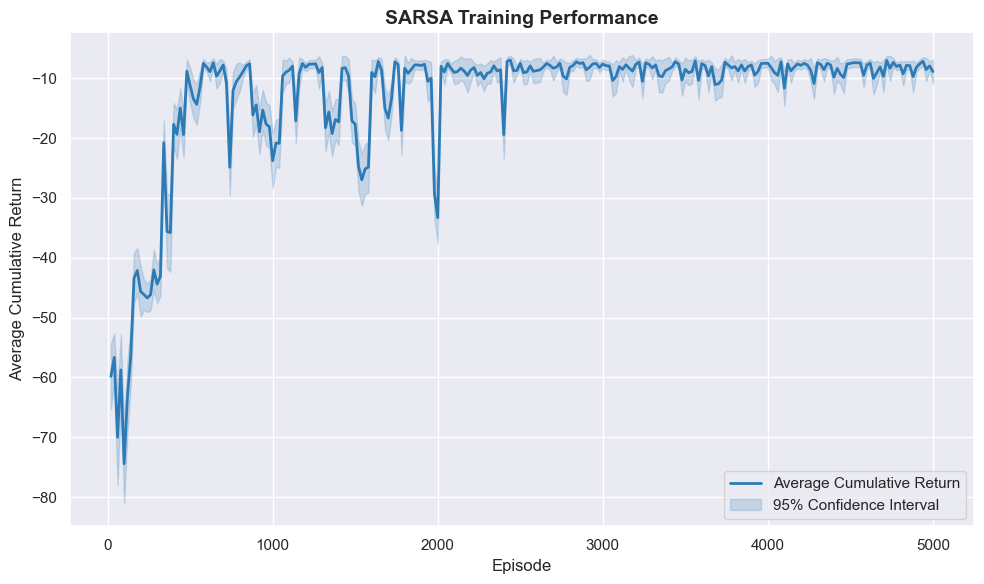

In [35]:
seed_everything(42)

env = gym.make(CLIFF_WALKING_ENV_NAME, render_mode='rgb_array')
policy, mean_returns, margins_of_error = SARSA(env, (4, 12), 4)

plot_training_results(alg_name='SARSA', mean_returns=mean_returns, confidence_intervals=margins_of_error)

Let's visualize the behavior of the agent with the greedy policy.

In [36]:
seed_everything(42)

policy.epsilon = 0.0
frames, _, _, _ = rollout(env, policy)

animate_frames(frames)

c:\Users\USER\Desktop\U\2026-2\Aprendizaje reforzado\rl-basics\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


**$Q$-Learning.** The $Q$-Learning algorithm is an **off-policy** Temporal Difference (TD) control method. It directly estimates the optimal action-value function $Q^*$, regardless of the exploratory policy being followed by the agent. In particular, the sampled action is obtained from a behavioral policy that needs not be the one that we are improving. For example, we can consider an $\epsilon$-greedy policy where $\epsilon$ is fixed and still reach convergence. This is obtained thanks to a different update rule for the estimate $\hat{Q}^*$.

<br> In particular, the algorithm works as follows.
<br> **Initialize** $\hat{Q}^*(s, a) \gets 0$, $N(s, a) \gets 0$, for every $s \in \mathcal{S}, a \in \mathcal{A}$ and $t \gets 1$
<br> **For every episode**:
<br> **Sample** $S \sim \mu_0$
<br> 
<br> **Repeat until end of the episode**:
1. **Increment** $t \gets t + 1$
2. **Sample** $A \sim \pi^{\text{g}}_{\hat{Q}^*, \epsilon}(S)$
3. **Take action** $A$ and observe reward $R$ and next-state $S'$
4. **Increment** $N(S, A) \gets N(S, A) + 1$
5. **Update** $\hat{Q}^*(S, A) \gets \hat{Q}^*(S, A) + \alpha_{N(S, A)} (R + \gamma \max_{a \in \mathcal{A}} \hat{Q}^*(S', a) - \hat{Q}^*(S, A))$
6. **Update** $S \gets S'$

_Remark._ We chose $\alpha_n$ which satisfies the Robbins-Monro conditions.

**⭐ Exercise.** Complete the implementation of $Q$-learning for environments with state space with shape `state_shape` (with the `numpy` meaning) and action space $\mathcal{A} = \{ 0, \dots, N_{\mathcal{A}} - 1 \}$, where $N_{\mathcal{A}}$ is provided as `actions_cardinality`. 

The function takes in input `n_episodes` which is the number of episodes used for training, as well as a fixed `epsilon` argument to be used by the $\epsilon$-greedy behavior policy (as remarked in the theoretical introduction). 
The `eval_every` attribute is the number of episodes after which we run an evaluation of the current policy: this behavior is already implemented.
Use the learning rate $\alpha_n = 0.1 \frac{c}{c+n}$ where $c$ is taken in input by the algorithm as `c`.

_Hint._ Remember to update $\hat{Q}^*$ in the $\epsilon$-greedy policy. You can do so by accessing the attributes directly. Keep in mind the off-policy nature of the temporal difference target. Since $\epsilon$ is fixed, you do not need to update it inside the episode loop.

In [ ]:
import numpy as np

def Q_learning(env, state_shape, actions_cardinality, discount_factor=1.0, epsilon=0.5, c=200., n_episodes=5000, eval_every=20):
    t = 1
    policy = EpsilonGreedyPolicy(state_shape, epsilon, actions_cardinality)
    N = np.zeros(shape=(*state_shape, actions_cardinality))
    
    mean_returns = []
    margins_of_error = []
    evaluation_count = 0
    
    for episode in range(n_episodes):
        state, _ = env.reset()
        done = False

        while not done:
            # Your code goes here: -------------------------------------
            ...
            # ----------------------------------------------------------

        if (episode + 1) % eval_every == 0:
            policy.epsilon = 0.0
            mean_return, margin = evaluate_policy(env, policy, discount_factor=discount_factor)
            policy.epsilon = epsilon
            mean_returns.append(mean_return)
            margins_of_error.append(margin)

            evaluation_count += 1
            if evaluation_count % 20 == 0:
                clear_output(wait=True)

    return policy, mean_returns, margins_of_error

Let's **try** the $Q$-Learning algorithm on the _cliff walking_ environment.

In [ ]:
seed_everything(42)

env = gym.make(CLIFF_WALKING_ENV_NAME, render_mode='rgb_array')
policy, mean_returns, margins_of_error = Q_learning(env, (4, 12), 4)

plot_training_results(alg_name='$Q$-Learning', mean_returns=mean_returns, confidence_intervals=margins_of_error)

Let's visualize the behavior of the agent with the greedy policy.

In [ ]:
seed_everything(42)

policy.epsilon = 0.0
frames, _, _, _ = rollout(env, policy)

animate_frames(frames)

**⭐ Exercise.** Train a RL agent for the _Milan taxi_ environment.

In [ ]:
# Your code goes here: -------------------------------------
...
# ----------------------------------------------------------

In [ ]:
policy.epsilon = 0.0
frames, _, _, _ = rollout(env, policy)

animate_frames(frames)

---

### Source

Adapted from the **Reinforcement Learning Summer School 2026 (RLSS26)**, Milan, Italy — *RL Basics I: Introduction to Reinforcement Learning*.

Original authors (Politecnico di Milano): [Enea Gusmeroli](mailto:enea.gusmeroli@polimi.it) **•** [Cristiano Migali](mailto:cristiano.migali@polimi.it) **•** [Davide Salaorni](mailto:davide.salaorni@polimi.it) **•** [Gianmarco Tedeschi](mailto:gianmarco.tedeschi@polimi.it)

Original materials: [github.com/gianmtedeschi/tutorial-rlss26](https://github.com/gianmtedeschi/tutorial-rlss26)
